In [ ]:
## CLIMADA 

In [22]:
from climada.entity import Exposures
from climada.entity.impact_funcs.base import ImpactFunc
from climada.entity.impact_funcs.impact_func_set import ImpactFuncSet
import numpy as np
import xarray as xr
from pyproj import Transformer
from scipy import sparse
import matplotlib.pyplot as plt
from climada.hazard import Hazard
from climada.engine import Impact
from climada.hazard.centroids.centr import Centroids

# --- INPUTS ---
HAZARD_ZELL = "/storage/homefs/ge24z347/LISFLOOD_FP_8_1/build/Zell_2m/Zell_2m_lisflood.nc"
VAR_NAME    = "water_depth"   # variable name in your NetCDF
GRID_EPSG   = 2056            # CRS of x/y in the NetCDF (LV95)
WET_THRESH  = 0.05            # set to 0.0 if you want to keep everything

# --- Read NetCDF ---
ds = xr.open_dataset(HAZARD_ZELL)
da = ds[VAR_NAME]
# Ensure dims are (step, y, x); if 2-D, make it 3-D with a singleton 'step'
if "step" not in da.dims:
    da = da.expand_dims(step=[0])
if list(da.dims) != ["lead_time", "y", "x"]:
    da = da.transpose("lead_time", "y", "x")

# --- Grid coords ---
x = da["x"].values
y = da["y"].values
X, Y = np.meshgrid(x, y)              # shapes (ny, nx)
ny, nx = Y.shape
n_cent = ny * nx

# --- Transform to WGS84 for CLIMADA centroids ---
transformer = Transformer.from_crs(GRID_EPSG, 4326, always_xy=True)
lon, lat = transformer.transform(X.ravel(order="C"), Y.ravel(order="C"))
cent = Centroids.from_lat_lon(lat=lat, lon=lon)

# --- Intensities: apply threshold, reshape to (events x centroids) ---
arr = da.values  # (n_steps, ny, nx)
arr = np.where(arr >= WET_THRESH, arr, 0.0)   # keep depths >= threshold
intensity_2d = arr.reshape(arr.shape[0], n_cent)

# --- Build Hazard("FL") ---
haz = Hazard("FL")
haz.centroids = cent
haz.units = "m"

n_events = intensity_2d.shape[0]
haz.event_id   = np.arange(1, n_events + 1, dtype=int)
haz.event_name = np.array([f"lead_time_{i:04d}" for i in range(n_events)], dtype="U16")
haz.date       = np.full(n_events, 20250101, dtype=int)  # placeholder date tags
haz.frequency  = np.ones(n_events, dtype=float)

# ★ assign intensity matrix (events x centroids)
haz.intensity  = sparse.csr_matrix(intensity_2d)

# --- Sanity checks ---
print("hazard events:", haz.size)
print("hazard intensity shape:", haz.intensity.shape)
print("centroids:", haz.centroids.size)

ValueError: ('lead_time', 'y', 'x') must be a permuted list of ('step', 'lead_time', 'x', 'y'), unless `...` is included

In [25]:
from climada.hazard import Hazard
from climada.hazard.centroids.centr import Centroids
from pyproj import Transformer
from scipy import sparse
import numpy as np
import xarray as xr

# --- INPUTS ---
HAZARD_ZELL = "/storage/homefs/ge24z347/LISFLOOD_FP_8_1/build/Zell_2m/Zell_2m_lisflood.nc"
VAR_NAME    = "water_depth"
GRID_EPSG   = 2056
WET_THRESH  = 0.05  # set 0.0 if you want everything

# --- Read ---
ds = xr.open_dataset(HAZARD_ZELL)
da = ds[VAR_NAME]

# Detect time dimension name
time_dim = "lead_time" if "lead_time" in da.dims else ("step" if "step" in da.dims else None)

# If there is no time dimension (2-D raster), create one called 'lead_time'
if time_dim is None:
    time_dim = "lead_time"
    da = da.expand_dims({time_dim: [0]})

# Make sure ordering is (time, y, x)
want_order = (time_dim, "y", "x")
da = da.transpose(*[d for d in want_order if d in da.dims])  # safe transpose

# --- Grid coords ---
x = da["x"].values
y = da["y"].values
X, Y = np.meshgrid(x, y)
ny, nx = Y.shape
n_cent = ny * nx

# --- Transform to WGS84 for CLIMADA centroids ---
transformer = Transformer.from_crs(GRID_EPSG, 4326, always_xy=True)
lon, lat = transformer.transform(X.ravel(order="C"), Y.ravel(order="C"))
cent = Centroids.from_lat_lon(lat=lat, lon=lon)

# --- Intensities (events × centroids) ---
arr = da.values  # shape: (n_time, ny, nx)
arr = np.where(arr >= WET_THRESH, arr, 0.0)
intensity_2d = arr.reshape(arr.shape[0], n_cent)

# Build event metadata from coord values if available
if time_dim in ds.coords:
    tvals = ds[time_dim].values
    # stringify lead times cleanly
    try:
        # Try to format numeric lead times (e.g., 0..12 hours)
        event_name = np.array([f"{time_dim}_{float(v):g}" for v in tvals], dtype="U32")
    except Exception:
        # Fallback generic
        event_name = np.array([f"{time_dim}_{i:04d}" for i in range(len(tvals))], dtype="U16")
else:
    event_name = np.array([f"{time_dim}_{i:04d}" for i in range(arr.shape[0])], dtype="U16")

# --- Build Hazard("FL") ---
haz = Hazard("FL")
haz.centroids = cent
haz.units = "m"

n_events = intensity_2d.shape[0]
haz.event_id   = np.arange(1, n_events + 1, dtype=int)
haz.event_name = event_name
haz.date       = np.full(n_events, 20250101, dtype=int)  # placeholder
haz.frequency  = np.ones(n_events, dtype=float)

haz.intensity  = sparse.csr_matrix(intensity_2d)

# --- Sanity ---
print("time dim:", time_dim)
print("hazard events:", haz.size)
print("hazard intensity shape:", haz.intensity.shape)
print("centroids:", haz.centroids.size)


/tmp/ipykernel_2333640/3154912983.py:40: DeprecatedWarning: from_lat_lon is deprecated. This method will be removed in a future version. Simply use the constructor instead.
  cent = Centroids.from_lat_lon(lat=lat, lon=lon)


time dim: lead_time
hazard events: 13
hazard intensity shape: (13, 1500000)
centroids: 1500000


<GeoAxes: title={'center': 'Event ID 11: lead_time_10'}>

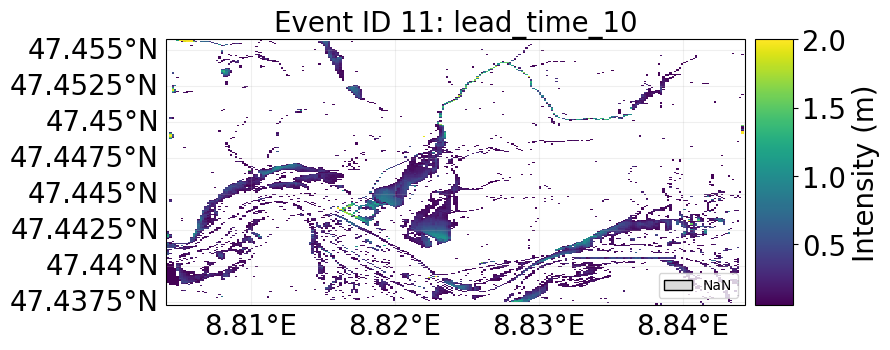

In [26]:
haz.plot_intensity(11, vmin=0.05, vmax=2)  # 0–2 m

In [ ]:
EXPOSURE 

(13, 1500000)

In [ ]:
EXPOSURE = "/rs_scratch/users/ge24z347/Data_forprocess/geo_hwr_footp_tlm2023.shp" 

In [27]:
ds_cosmo  = xr.open_dataset("/storage/homefs/ge24z347/Liestal_event/Data_forprocess/COSMO/cosmo1e_2022-05-05T12.nc")  
ds_icon  = xr.open_dataset("/storage/homefs/ge24z347/Liestal_event/Data_forprocess/ICON_Forecast/icon_forecasts_june_24_swiss_radar_grid.nc")
HAZARD = xr.open_dataset("/storage/homefs/ge24z347/LISFLOOD_FP_8_1/build/Zell_2m/Zell_2m_lisflood.nc")
       

/tmp/ipykernel_2333640/1810944190.py:1: FutureWarning: In a future version of xarray decode_timedelta will default to False rather than None. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  ds_cosmo  = xr.open_dataset("/storage/homefs/ge24z347/Liestal_event/Data_forprocess/COSMO/cosmo1e_2022-05-05T12.nc")
/tmp/ipykernel_2333640/1810944190.py:2: FutureWarning: In a future version of xarray decode_timedelta will default to False rather than None. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  ds_icon  = xr.open_dataset("/storage/homefs/ge24z347/Liestal_event/Data_forprocess/ICON_Forecast/icon_forecasts_june_24_swiss_radar_grid.nc")


In [30]:
HAZARD

<xarray.Dataset> Size: 702MB
Dimensions:         (lead_time: 13, y: 1000, x: 1500)
Coordinates:
    spatial_ref     int64 8B ...
  * lead_time       (lead_time) int64 104B 0 1 2 3 4 5 6 7 8 9 10 11 12
  * y               (y) float64 8kB 1.257e+06 1.257e+06 ... 1.255e+06 1.255e+06
  * x               (x) float64 12kB 2.703e+06 2.703e+06 ... 2.706e+06 2.706e+06
Data variables:
    water_depth     (lead_time, x, y) float32 78MB ...
    vel_x_c         (lead_time, y, x) float32 78MB ...
    vel_y_c         (lead_time, y, x) float32 78MB ...
    flux_x_c        (lead_time, y, x) float32 78MB ...
    flux_y_c        (lead_time, y, x) float32 78MB ...
    vel_mag         (lead_time, y, x) float32 78MB ...
    flux_mag        (lead_time, y, x) float32 78MB ...
    discharge_cell  (lead_time, y, x) float32 78MB ...
    speed_cell      (lead_time, y, x) float32 78MB ...
Attributes:
    Conventions:    CF-1.8
    source:         LISFLOOD single-member ASCII series, cell-centred on wate...
    deterministic:  true

In [11]:
ds_cosmo['precipitation_amount'] 

<xarray.DataArray 'precipitation_amount' (forecast_reference_time: 1,
                                          lead_time: 34, realization: 11,
                                          y: 640, x: 710)> Size: 680MB
[169945600 values with dtype=float32]
Coordinates:
  * lead_time                (lead_time) timedelta64[ns] 272B 00:00:00 ... 1 ...
  * forecast_reference_time  (forecast_reference_time) datetime64[ns] 8B 2022...
  * realization              (realization) float64 88B 0.0 1.0 2.0 ... 9.0 10.0
    time                     (forecast_reference_time, lead_time) datetime64[ns] 272B ...
  * y                        (y) int64 5kB 840500 841500 ... 1478500 1479500
  * x                        (x) int64 6kB 2255500 2256500 ... 2963500 2964500
Attributes:
    units:              kg m-2
    availability_time:  {"2022-05-05T12:00:00": "2022-06-25T11:56:09.516065"}

In [ ]:
da = ds_cosmo['precipitation_amount'].isel(lead_time=6, realization=3)
da.values 

array([[[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]]],
      shape=(1, 640, 710), dtype=float32)

/tmp/ipykernel_1308997/2440040452.py:11: FutureWarning: In a future version of xarray decode_timedelta will default to False rather than None. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  ds = xr.open_dataset(cosmo_file, decode_times=True)


ICON Y coords: 840500 → 1479500
DEM Y bounds: 1255000.0 → 1257000.0
Cropped window shape: (2, 3)


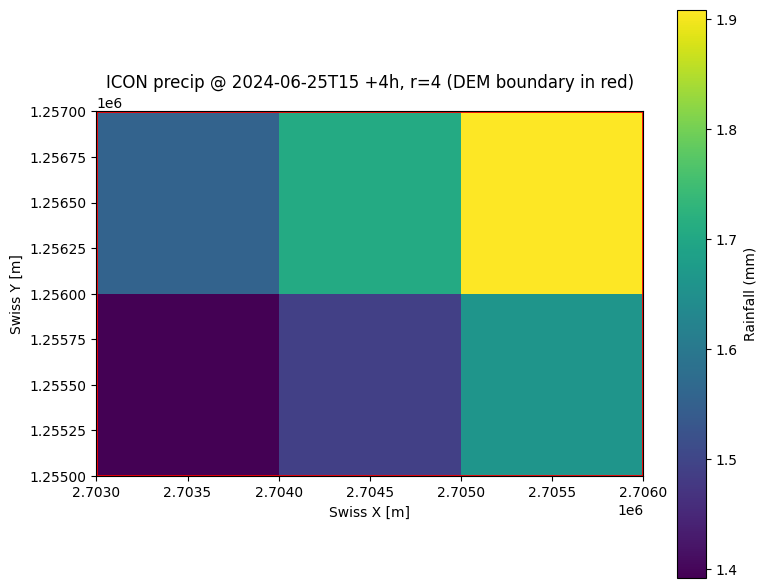

In [17]:
import xarray as xr
import numpy as np
import rasterio
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

cosmo_file = "/storage/homefs/ge24z347/Liestal_event/Data_forprocess/COSMO/cosmo1e_2022-05-05T12.nc"  
dem_file  = "/storage/homefs/ge24z347/LISFLOOD_FP_8_1/build/Zell_2m/Zell_2m.dem"

# pick the exact field
ds = xr.open_dataset(cosmo_file, decode_times=True)
precip = ds["precipitation_amount"].sel(
    forecast_reference_time = "2022-05-05T12:00:00",
    lead_time               = np.timedelta64(6, "h"),
    realization             = 2,
    method                  = "nearest"
)

# DEM bounds
with rasterio.open(dem_file) as src:
    left, bottom, right, top = src.bounds

print("ICON Y coords:", precip.y.min().item(), "→", precip.y.max().item())
print("DEM Y bounds:", bottom, "→", top)

# *** CORRECT SLICE: bottom → top ***
precip_win = precip.sel(
    x = slice(left,  right),
    y = slice(bottom, top)
)

print("Cropped window shape:", precip_win.shape)  # should now be non-zero

# plot
fig, ax = plt.subplots(figsize=(8,6))
precip_win.plot(
    ax          = ax,
    cmap        = "viridis",
    cbar_kwargs = {"label":"Rainfall (mm)"}
)
rect = Rectangle(
    (left, bottom),
    right-left,
    top-bottom,
    fill=False, edgecolor="red", linewidth=2
)
ax.add_patch(rect)
ax.set_aspect("equal", "box")
ax.set_title("ICON precip @ 2024-06-25T15 +4h, r=4 (DEM boundary in red)")
ax.set_xlabel("Swiss X [m]")
ax.set_ylabel("Swiss Y [m]")
plt.tight_layout()
plt.show()

In [18]:
precip_win.values

array([[1.3924805, 1.489896 , 1.6613581],
       [1.5550426, 1.7066585, 1.9089696]], dtype=float32)

In [9]:
cosmo_file_3 = "/storage/homefs/ge24z347/LISFLOOD_FP_8_1/build/Zell_2m/Zell_2m_3.nc"  
dem_file  = "/storage/homefs/ge24z347/LISFLOOD_FP_8_1/build/Zell_2m/Zell_2m.dem"

# pick the exact field
ds = xr.open_dataset(cosmo_file_3, decode_times=True)
ds

<xarray.Dataset> Size: 348B
Dimensions:         (time: 11, x: 3, y: 2)
Coordinates:
  * time            (time) float32 44B 0.0 1.0 2.0 3.0 4.0 ... 7.0 8.0 9.0 10.0
  * x               (x) float64 24B 2.704e+06 2.704e+06 2.706e+06
  * y               (y) float64 16B 1.256e+06 1.256e+06
Data variables:
    rainfall_depth  (time, y, x) float32 264B ...
Attributes:
    description:  Cropped ICON rainfall, realization 3
    history:      Created on 2025-10-05
    source:       ICON forecast cropped to DEM box (no resampling)

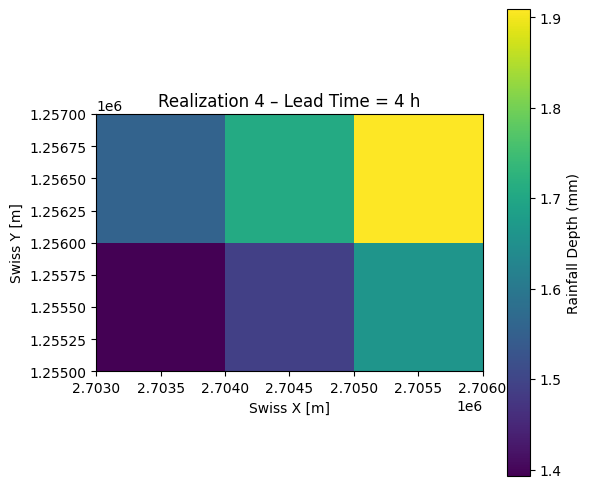

In [15]:
import xarray as xr
import matplotlib.pyplot as plt

# 1) Open the file
Liestal_4 = "/storage/homefs/ge24z347/LISFLOOD_FP_8_1/build/Zell_2m/Zell_2m_3.nc"
ds_icon_4 = xr.open_dataset(Liestal_4, decode_times=False)

# 2) Select the 4 h lead
rain4h = ds_icon_4["rainfall_depth"].sel(time=6)

# 3) Plot
plt.figure(figsize=(6,5))
rain4h.plot(
    cmap="viridis",
    cbar_kwargs={"label":"Rainfall Depth (mm)"}
)
plt.title("Realization 4 – Lead Time = 4 h")
plt.xlabel("Swiss X [m]")
plt.ylabel("Swiss Y [m]")
plt.gca().set_aspect("equal")
plt.tight_layout()
plt.show()

In [16]:
rain4h.values

array([[1.3924805, 1.489896 , 1.6613581],
       [1.5550426, 1.7066585, 1.9089696]], dtype=float32)

In [2]:
Liestal_3 = "/storage/homefs/ge24z347/LISFLOOD_FP_8_1/build/Liestal_2m/Liestal_2m_3.nc"
ds_icon_3 = xr.open_dataset(Liestal_3, decode_times=False)
ds_icon_3

<xarray.Dataset> Size: 812B
Dimensions:         (time: 11, x: 4, y: 4)
Coordinates:
  * time            (time) float32 44B 0.0 1.0 2.0 3.0 4.0 ... 7.0 8.0 9.0 10.0
  * x               (x) float64 32B 2.62e+06 2.62e+06 2.622e+06 2.622e+06
  * y               (y) float64 32B 1.258e+06 1.258e+06 1.26e+06 1.26e+06
Data variables:
    rainfall_depth  (time, y, x) float32 704B ...
Attributes:
    description:  Cropped ICON rainfall, realization 3
    history:      Created on 2025-06-27
    source:       ICON forecast cropped to DEM box (no resampling)

In [5]:
ds_cosmo_real  = xr.open_dataset("/storage/homefs/ge24z347/LISFLOOD_FP_8_1/build/Zell_2m/Zell_2m_3.nc")  
ds_cosmo_real 

<xarray.Dataset> Size: 348B
Dimensions:         (time: 11, x: 3, y: 2)
Coordinates:
  * time            (time) float32 44B 0.0 1.0 2.0 3.0 4.0 ... 7.0 8.0 9.0 10.0
  * x               (x) float64 24B 2.704e+06 2.704e+06 2.706e+06
  * y               (y) float64 16B 1.256e+06 1.256e+06
Data variables:
    rainfall_depth  (time, y, x) float32 264B ...
Attributes:
    description:  Cropped ICON rainfall, realization 3
    history:      Created on 2025-10-05
    source:       ICON forecast cropped to DEM box (no resampling)

In [7]:
ds_icon_3

<xarray.Dataset> Size: 68B
Dimensions:         (time: 1, x: 3, y: 2)
Coordinates:
  * time            (time) float32 4B 0.0
  * x               (x) float64 24B 2.704e+06 2.704e+06 2.706e+06
  * y               (y) float64 16B 1.256e+06 1.256e+06
Data variables:
    rainfall_depth  (time, y, x) float32 24B ...
Attributes:
    description:  Cropped rainfall, realization 3
    history:      Created on 2025-10-03
    source:       Forecast cropped to DEM bounding box (no resampling)

In [9]:
ds_icon ['precipitation_amount']

<xarray.DataArray 'precipitation_amount' (forecast_reference_time: 2,
                                          lead_time: 34, realization: 11,
                                          y: 640, x: 710)> Size: 1GB
[339891200 values with dtype=float32]
Coordinates:
  * lead_time                (lead_time) timedelta64[ns] 272B 00:00:00 ... 1 ...
  * forecast_reference_time  (forecast_reference_time) datetime64[ns] 16B 202...
  * realization              (realization) float64 88B 0.0 1.0 2.0 ... 9.0 10.0
    time                     (forecast_reference_time, lead_time) datetime64[ns] 544B ...
  * x                        (x) float32 3kB 2.256e+06 2.256e+06 ... 2.964e+06
  * y                        (y) float32 3kB 8.405e+05 8.415e+05 ... 1.48e+06
    longitude                (y, x) float32 2MB ...
    latitude                 (y, x) float32 2MB ...
    surface_altitude         (y, x) float32 2MB ...
Attributes:
    units:              kg m-2
    availability_time:  {"2024-06-25T15:00:00": "2024-06-25T17:23:41.243687",...

In [24]:
ds_lisflood  = xr.open_dataset("/storage/homefs/ge24z347/LISFLOOD_FP_8_1/build/Zell_2m/Zell_2m_lisflood.nc") 
ds_lisflood

<xarray.Dataset> Size: 6GB
Dimensions:         (realization: 11, lead_time: 10, y: 1000, x: 1500)
Coordinates:
  * realization     (realization) int64 88B 1 2 3 4 5 6 7 8 9 10 11
    spatial_ref     int64 8B ...
  * lead_time       (lead_time) int64 80B 1 2 3 4 5 6 7 8 9 10
  * y               (y) float64 8kB 1.257e+06 1.257e+06 ... 1.255e+06 1.255e+06
  * x               (x) float64 12kB 2.703e+06 2.703e+06 ... 2.706e+06 2.706e+06
Data variables:
    water_depth     (realization, lead_time, y, x) float32 660MB ...
    vel_x_c         (realization, lead_time, y, x) float32 660MB ...
    vel_y_c         (realization, lead_time, y, x) float32 660MB ...
    flux_x_c        (realization, lead_time, y, x) float32 660MB ...
    flux_y_c        (realization, lead_time, y, x) float32 660MB ...
    vel_mag         (realization, lead_time, y, x) float32 660MB ...
    flux_mag        (realization, lead_time, y, x) float32 660MB ...
    discharge_cell  (realization, lead_time, y, x) float32 660MB ...
    speed_cell      (realization, lead_time, y, x) float32 660MB ...
Attributes:
    Conventions:  CF-1.8
    source:       Aggregated LISFLOOD ASCII outputs (cell-centred, wd-sized)

In [4]:
import os
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
from PIL import Image
from matplotlib.colors import ListedColormap, BoundaryNorm

# ────────────────────────────────────────────────────────────────────────────────
# High-quality Swisstopo WMS fetch (pixel size in meters; clamped by max_px)
# ────────────────────────────────────────────────────────────────────────────────
def get_swisstopo_background_image_hq(xmin, xmax, ymin, ymax,
                                      pixel_size_m=1.0,
                                      layer="ch.swisstopo.swisstlm3d-karte-grau",
                                      max_px=4096):
    import requests
    from io import BytesIO

    width  = int(max(1, round((xmax - xmin) / float(pixel_size_m))))
    height = int(max(1, round((ymax - ymin) / float(pixel_size_m))))

    scale = max(width / max_px, height / max_px, 1.0)
    width  = int(width / scale)
    height = int(height / scale)

    params = {
        "SERVICE": "WMS",
        "REQUEST": "GetMap",
        "VERSION": "1.3.0",
        "LAYERS": layer,
        "BBOX": f"{xmin},{ymin},{xmax},{ymax}",
        "CRS": "EPSG:2056",
        "WIDTH": width,
        "HEIGHT": height,
        "FORMAT": "image/png",
        "TRANSPARENT": "TRUE",
    }
    headers = {"User-Agent": "Mozilla/5.0", "Accept": "image/png,image/*,*/*;q=0.8"}
    r = requests.get("https://wms.geo.admin.ch/", params=params, headers=headers, timeout=60)
    r.raise_for_status()
    return Image.open(BytesIO(r.content))

# ────────────────────────────────────────────────────────────────────────────────
# Main plotting
# ────────────────────────────────────────────────────────────────────────────────
def plot_all_water_depths(nc_path, out_dir,
                          threshold=0.01,
                          vmax=2.0,
                          bg_pixel_size=1.0,
                          bg_max_px=4096,
                          layer="ch.swisstopo.swisstlm3d-karte-grau",
                          case_label="Zell",
                          init_time_str=None,
                          extent=None,           # (xmin, xmax, ymin, ymax)
                          extent_units="auto",
                          min_fig_height=6.0):

    def _as_hours(v, ref0=None):
        if np.isscalar(v) and isinstance(v, (int, float, np.integer, np.floating)):
            return float(v)
        if np.issubdtype(np.asarray(v).dtype, np.timedelta64):
            return float(v / np.timedelta64(1, "h"))
        if np.issubdtype(np.asarray(v).dtype, np.datetime64):
            if ref0 is None:
                return 0.0
            return float((v - ref0) / np.timedelta64(1, "h"))
        try:
            return float(v)
        except Exception:
            return 0.0

    def _extent_to_meters(ext, units):
        if ext is None:
            return None
        xmin, xmax, ymin, ymax = ext
        if units == "m":
            return (xmin, xmax, ymin, ymax)
        if units == "km":
            return (xmin*1000.0, xmax*1000.0, ymin*1000.0, ymax*1000.0)
        # auto: treat as km if numbers are small
        sample = max(abs(v) for v in ext)
        return (xmin*1000.0, xmax*1000.0, ymin*1000.0, ymax*1000.0) if sample < 10000 else (xmin, xmax, ymin, ymax)

    os.makedirs(out_dir, exist_ok=True)
    ds = xr.open_dataset(nc_path)

    # dims/vars
    time_dim = "lead_time" if "lead_time" in ds.dims else ("step" if "step" in ds.dims else None)
    if time_dim is None:
        raise ValueError("Couldn't find a time dimension named 'lead_time' or 'step'.")
    if "realization" not in ds.dims:
        raise ValueError("Dataset must have a 'realization' dimension.")
    if "water_depth" not in ds.data_vars:
        raise ValueError("Variable 'water_depth' not found in dataset.")

    # init time (from file if not provided)
    if init_time_str is None and "forecast_reference_time" in ds.coords:
        frt = ds["forecast_reference_time"].values
        frt0 = frt.item() if np.ndim(frt) == 0 else frt[0]
        init_time_str = np.datetime_as_string(frt0, unit="s")

    # domain extents
    x_all = ds["x"].values
    y_all = ds["y"].values
    dom_xmin, dom_xmax = float(np.min(x_all)), float(np.max(x_all))
    dom_ymin, dom_ymax = float(np.min(y_all)), float(np.max(y_all))

    # zoom extent (clamped to domain)
    if extent is None:
        xmin, xmax, ymin, ymax = dom_xmin, dom_xmax, dom_ymin, dom_ymax
    else:
        xmin_i, xmax_i, ymin_i, ymax_i = _extent_to_meters(extent, extent_units)
        xmin = max(dom_xmin, min(xmin_i, xmax_i))
        xmax = min(dom_xmax, max(xmin_i, xmax_i))
        ymin = max(dom_ymin, min(ymin_i, ymax_i))
        ymax = min(dom_ymax, max(ymin_i, ymax_i))

    # north-up config
    plot_extent = (xmin, xmax, ymin, ymax)   # for origin='lower'
    plot_origin = "lower"

    # selection slices (respect native order)
    x_asc = x_all[0] < x_all[-1]
    y_asc = y_all[0] < y_all[-1]
    xsel = slice(xmin, xmax) if x_asc else slice(xmax, xmin)
    ysel = slice(ymin, ymax) if y_asc else slice(ymax, ymin)

    # high-quality background for the exact window
    try:
        bg = get_swisstopo_background_image_hq(
            xmin, xmax, ymin, ymax,
            pixel_size_m=bg_pixel_size, layer=layer, max_px=bg_max_px
        )
    except Exception as e:
        print(f"⚠️  WMS fetch failed ({e}). Proceeding without background.")
        bg = None

    # discrete YlGnBu-ish palette (+ overflow color)
    edges = [0.01, 0.10, 0.30, 0.50, 1.0, 1.50, 2.0]
    colors = ["#f7fcf0", "#ccebc5", "#a8ddb5", "#7bccc4", "#43a2ca", "#0868ac"]
    colors_ext = colors + ["#023858"]   # ≥ 2.0
    cmap_disc = ListedColormap(colors_ext)
    cmap_disc.set_under((0, 0, 0, 0))
    norm = BoundaryNorm(edges, cmap_disc.N, extend='max')

    reals = ds["realization"].values
    times = ds[time_dim].values
    time_ref0 = times[0] if np.issubdtype(np.asarray(times).dtype, np.datetime64) else None

    # figure sizing
    xspan = xmax - xmin
    yspan = ymax - ymin
    base_w = 8.0
    fig_h = max(min_fig_height, base_w * (yspan / xspan))

    for r in reals:
        # crop to window
        da_r = ds["water_depth"].sel(realization=r, x=xsel, y=ysel)

        # detect axis order AFTER cropping
        x_sel = da_r["x"].values
        y_sel = da_r["y"].values
        x_desc = x_sel[0] > x_sel[-1]
        y_desc = y_sel[0] > y_sel[-1]

        for t_idx, t_val in enumerate(times):
            da_rt = da_r.isel({time_dim: t_idx}).transpose("y", "x")
            arr = da_rt.values.astype(np.float32)

            # flip array to match origin='lower' (y up, x right)
            if y_desc:
                arr = arr[::-1, :]
            if x_desc:
                arr = arr[:, ::-1]

            # mask below threshold
            arr = np.where(arr >= threshold, arr, np.nan)

            # title with lead time
            lead_h = _as_hours(t_val, ref0=time_ref0)
            lead_txt = f"{lead_h:.0f} h" if abs(lead_h - round(lead_h)) < 1e-6 else f"{lead_h:.1f} h"
            title = f"{case_label} — {init_time_str if init_time_str else 'init time unknown'} + {lead_txt} lead time"

            fig, ax = plt.subplots(figsize=(base_w, fig_h), dpi=150)

            # draw background (flip image vertically to match origin='lower')
            if bg is not None:
                bg_np = np.array(bg)[::-1, :, :]   # **critical fix**
                ax.imshow(bg_np, extent=plot_extent, origin="lower", interpolation="nearest")

            # overlay
            ax.imshow(arr, extent=plot_extent, origin="lower",
                      cmap=cmap_disc, norm=norm, interpolation="nearest")

            ax.set_title(title, fontsize=20, fontweight="bold")
            ax.set_xlabel("")
            ax.set_ylabel("")
            ax.set_aspect("equal"); ax.grid(False)
            ax.set_xlim(xmin, xmax); ax.set_ylim(ymin, ymax)

            #  no ticks
            ax.tick_params(left=False, right=False, bottom=False, top=False,
            labelleft=False, labelright=False, labelbottom=False, labeltop=False)

            safe_t = str(t_val).replace(":", "-").replace(" ", "_")
            tag_zoom = "_zoom" if extent is not None else ""
            out_png = os.path.join(out_dir, f"wd_r{int(r)}_{time_dim}{safe_t}{tag_zoom}.png")
            plt.savefig(out_png, bbox_inches="tight")
            plt.close(fig)
            print(f" saved {out_png}")

    ds.close()
    ticks = [t for t in edges if (t >= threshold and t <= vmax)] or [threshold, vmax]
    return cmap_disc, norm, ticks, vmax

In [5]:
plot_all_water_depths(
    nc_path="/storage/homefs/ge24z347/LISFLOOD_FP_8_1/build/Zell_2m/Zell_2m_lisflood.nc",
    out_dir="/storage/homefs/ge24z347/Liestal_event/ZELL_PLOTS/Zell_2m_COSMO/",
    threshold=0.01, vmax=2.0,
    case_label="Zell",
    init_time_str="2022-05-05T12:00:00",
    extent=(2703600, 2704800, 1256770, 1255250),  # xmin, xmax, ymin, ymax
    extent_units="m"
)

ValueError: Dataset must have a 'realization' dimension.

In [ ]:
### Deterministic 

In [1]:
import os
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
from PIL import Image
from matplotlib.colors import ListedColormap, BoundaryNorm

def get_swisstopo_background_image_hq(xmin, xmax, ymin, ymax,
                                      pixel_size_m=1.0,
                                      layer="ch.swisstopo.swisstlm3d-karte-grau",
                                      max_px=4096):
    import requests
    from io import BytesIO

    width  = int(max(1, round((xmax - xmin) / float(pixel_size_m))))
    height = int(max(1, round((ymax - ymin) / float(pixel_size_m))))
    scale = max(width / max_px, height / max_px, 1.0)
    width  = int(width / scale)
    height = int(height / scale)

    params = {
        "SERVICE": "WMS", "REQUEST": "GetMap", "VERSION": "1.3.0",
        "LAYERS": layer,
        "BBOX": f"{xmin},{ymin},{xmax},{ymax}",
        "CRS": "EPSG:2056",
        "WIDTH": width, "HEIGHT": height,
        "FORMAT": "image/png", "TRANSPARENT": "TRUE",
    }
    headers = {"User-Agent": "Mozilla/5.0", "Accept": "image/png,image/*,*/*;q=0.8"}
    r = requests.get("https://wms.geo.admin.ch/", params=params, headers=headers, timeout=60)
    r.raise_for_status()
    return Image.open(BytesIO(r.content))

def plot_water_depths_deterministic(nc_path, out_dir,
                                    threshold=0.01, vmax=2.0,
                                    bg_pixel_size=1.0, bg_max_px=4096,
                                    layer="ch.swisstopo.swisstlm3d-karte-grau",
                                    case_label="Zell", init_time_str=None,
                                    extent=None, extent_units="auto",
                                    min_fig_height=6.0):
    """Plots water_depth from a NetCDF that has NO 'realization' dim."""
    def _as_hours(v, ref0=None):
        if np.isscalar(v) and isinstance(v, (int, float, np.integer, np.floating)): return float(v)
        if np.issubdtype(np.asarray(v).dtype, np.timedelta64): return float(v / np.timedelta64(1, "h"))
        if np.issubdtype(np.asarray(v).dtype, np.datetime64):
            if ref0 is None: return 0.0
            return float((v - ref0) / np.timedelta64(1, "h"))
        try: return float(v)
        except Exception: return 0.0

    def _extent_to_meters(ext, units):
        if ext is None: return None
        xmin, xmax, ymin, ymax = ext
        if units == "m":  return (xmin, xmax, ymin, ymax)
        if units == "km": return (xmin*1000.0, xmax*1000.0, ymin*1000.0, ymax*1000.0)
        return (xmin*1000.0, xmax*1000.0, ymin*1000.0, ymax*1000.0) if max(abs(v) for v in ext) < 10000 else (xmin, xmax, ymin, ymax)

    os.makedirs(out_dir, exist_ok=True)
    ds = xr.open_dataset(nc_path)

    # pick time dim and variable
    time_dim = "lead_time" if "lead_time" in ds.dims else ("step" if "step" in ds.dims else None)
    if time_dim is None: raise ValueError("Couldn't find a time dimension named 'lead_time' or 'step'.")
    if "water_depth" not in ds.data_vars: raise ValueError("Variable 'water_depth' not found in dataset.")

    # init time string if present
    if init_time_str is None and "forecast_reference_time" in ds.coords:
        frt = ds["forecast_reference_time"].values
        frt0 = frt.item() if np.ndim(frt) == 0 else frt[0]
        init_time_str = np.datetime_as_string(frt0, unit="s")

    # domain / extent
    x_all = ds["x"].values; y_all = ds["y"].values
    dom_xmin, dom_xmax = float(np.min(x_all)), float(np.max(x_all))
    dom_ymin, dom_ymax = float(np.min(y_all)), float(np.max(y_all))
    if extent is None:
        xmin, xmax, ymin, ymax = dom_xmin, dom_xmax, dom_ymin, dom_ymax
    else:
        xmin_i, xmax_i, ymin_i, ymax_i = _extent_to_meters(extent, extent_units)
        xmin = max(dom_xmin, min(xmin_i, xmax_i))
        xmax = min(dom_xmax, max(xmin_i, xmax_i))
        ymin = max(dom_ymin, min(ymin_i, ymax_i))
        ymax = min(dom_ymax, max(ymin_i, ymax_i))

    # north-up plotting config
    plot_extent = (xmin, xmax, ymin, ymax)

    # slice window respecting native order
    x_asc = x_all[0] < x_all[-1]; y_asc = y_all[0] < y_all[-1]
    xsel = slice(xmin, xmax) if x_asc else slice(xmax, xmin)
    ysel = slice(ymin, ymax) if y_asc else slice(ymax, ymin)

    # fetch background
    try:
        bg = get_swisstopo_background_image_hq(xmin, xmax, ymin, ymax,
                                               pixel_size_m=bg_pixel_size,
                                               layer=layer, max_px=bg_max_px)
    except Exception as e:
        print(f"⚠️  WMS fetch failed ({e}). Proceeding without background.")
        bg = None

    # discrete palette
    edges = [0.01, 0.10, 0.30, 0.50, 1.0, 1.50, 2.0]
    colors = ["#f7fcf0", "#ccebc5", "#a8ddb5", "#7bccc4", "#43a2ca", "#0868ac"]
    cmap_disc = ListedColormap(colors + ["#023858"])  # last is overflow ≥ 2
    cmap_disc.set_under((0, 0, 0, 0))
    norm = BoundaryNorm(edges, cmap_disc.N, extend='max')

    # figure sizing
    xspan = xmax - xmin; yspan = ymax - ymin
    base_w = 8.0; fig_h = max(min_fig_height, base_w * (yspan / xspan))

    # select var and window
    da_wd = ds["water_depth"].sel(x=xsel, y=ysel)
    x_sel = da_wd["x"].values; y_sel = da_wd["y"].values
    x_desc = x_sel[0] > x_sel[-1]; y_desc = y_sel[0] > y_sel[-1]

    times = ds[time_dim].values
    time_ref0 = times[0] if np.issubdtype(np.asarray(times).dtype, np.datetime64) else None

    for t_idx, t_val in enumerate(times):
        da_t = da_wd.isel({time_dim: t_idx}).transpose("y", "x")
        arr = da_t.values.astype(np.float32)

        # flip array to match origin='lower' convention
        if y_desc: arr = arr[::-1, :]
        if x_desc: arr = arr[:, ::-1]

        # mask below threshold
        arr = np.where(arr >= threshold, arr, np.nan)

        # title
        lead_h = _as_hours(t_val, ref0=time_ref0)
        lead_txt = f"{lead_h:.0f} h" if abs(lead_h - round(lead_h)) < 1e-6 else f"{lead_h:.1f} h"
        title = f"{case_label} — {init_time_str if init_time_str else 'init time unknown'} + {lead_txt} lead time"

        fig, ax = plt.subplots(figsize=(base_w, fig_h), dpi=150)

        # draw background (flip vertically to match origin='lower')
        if bg is not None:
            bg_np = np.array(bg)[::-1, :, :]
            ax.imshow(bg_np, extent=plot_extent, origin="lower", interpolation="nearest")

        # overlay depths
        ax.imshow(arr, extent=plot_extent, origin="lower",
                  cmap=cmap_disc, norm=norm, interpolation="nearest")

        ax.set_title(title, fontsize=20, fontweight="bold")
        ax.set_xlabel(""); ax.set_ylabel("")
        ax.set_aspect("equal"); ax.grid(False)
        ax.set_xlim(xmin, xmax); ax.set_ylim(ymin, ymax)

        # hide ticks & labels
        ax.tick_params(left=False, right=False, bottom=False, top=False,
                       labelleft=False, labelright=False, labelbottom=False, labeltop=False)

        # save
        safe_t = str(t_val).replace(":", "-").replace(" ", "_")
        tag_zoom = "_zoom" if extent is not None else ""
        out_png = os.path.join(out_dir, f"wd_det_{time_dim}{safe_t}{tag_zoom}.png")
        plt.savefig(out_png, bbox_inches="tight")
        plt.close(fig)
        print(f"✅ saved {out_png}")

    ds.close()
    ticks = [t for t in edges if (t >= threshold and t <= vmax)] or [threshold, vmax]
    return cmap_disc, norm, ticks, vmax


In [3]:
plot_water_depths_deterministic(
    nc_path="/storage/homefs/ge24z347/LISFLOOD_FP_8_1/build/Zell_2m/Zell_2m_lisflood.nc",
    out_dir="/storage/homefs/ge24z347/Liestal_event/ZELL_PLOTS/Zell_2m_Combiprecip/",
    threshold=0.01, vmax=2.0,
    case_label="Zell",
    init_time_str="2022-05-05T08:00:00",
    extent=(2703600, 2704800, 1256770, 1255250),  # xmin, xmax, ymin, ymax
    extent_units="m"
)

✅ saved /storage/homefs/ge24z347/Liestal_event/ZELL_PLOTS/Zell_2m_Combiprecip/wd_det_lead_time0_zoom.png
✅ saved /storage/homefs/ge24z347/Liestal_event/ZELL_PLOTS/Zell_2m_Combiprecip/wd_det_lead_time1_zoom.png
✅ saved /storage/homefs/ge24z347/Liestal_event/ZELL_PLOTS/Zell_2m_Combiprecip/wd_det_lead_time2_zoom.png
✅ saved /storage/homefs/ge24z347/Liestal_event/ZELL_PLOTS/Zell_2m_Combiprecip/wd_det_lead_time3_zoom.png
✅ saved /storage/homefs/ge24z347/Liestal_event/ZELL_PLOTS/Zell_2m_Combiprecip/wd_det_lead_time4_zoom.png
✅ saved /storage/homefs/ge24z347/Liestal_event/ZELL_PLOTS/Zell_2m_Combiprecip/wd_det_lead_time5_zoom.png
✅ saved /storage/homefs/ge24z347/Liestal_event/ZELL_PLOTS/Zell_2m_Combiprecip/wd_det_lead_time6_zoom.png
✅ saved /storage/homefs/ge24z347/Liestal_event/ZELL_PLOTS/Zell_2m_Combiprecip/wd_det_lead_time7_zoom.png
✅ saved /storage/homefs/ge24z347/Liestal_event/ZELL_PLOTS/Zell_2m_Combiprecip/wd_det_lead_time8_zoom.png
✅ saved /storage/homefs/ge24z347/Liestal_event/ZELL_PLO

(<matplotlib.colors.ListedColormap at 0x7fa14e13d410>,
 [0.01, 0.1, 0.3, 0.5, 1.0, 1.5, 2.0],
 2.0)